<div style = "border: 1px solid black">
<b><center><font size = "5"> Projecto Prático 3 </font><center></b>

<b><center><font size = "3"> Aprendizagem Profunda Não Supervisionada
</font><center></b>
</div>



---



`Nome:` Leonor Rebola <br>
`Número:` 53663 <br>
`Curso:` Inteligência Artificial e Ciência de Dados <br>
`Email:` leonor.rebola@ubi.pt <br>
`UC:` Aprendizagem Computacional <br>


---



`Objetivo:` Desenvolver um modelo de aprendizagem não supervisionada que combine um autoencoder com métodos de clustering, permitindo agrupar imagens do dataset através das suas representações latentes.


---



# **Leitura do ficheiro**

---



In [ ]:
from google.colab import files
import zipfile
import os

# Ler o ficheiro
uploaded = files.upload()

# Para descompactar a pasta
zip_path = '/content/mnist.zip'
extract_path = '/content/'

os.makedirs(extract_path, exist_ok = True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

Saving mnist.zip to mnist.zip



# **Leitura e transformação das imagens**

---



In [ ]:
import numpy as np
from PIL import Image
import os

# Caminho da pasta descomprimida
base_path = '/content/mnist'

X = []
y = []

for filename in os.listdir(base_path):
    if filename.endswith('.png'):
        img_path = os.path.join(base_path, filename)
        img = Image.open(img_path).convert('L')  # grayscale
        img_array = np.array(img).astype('float32').flatten() # Transformar a imagem em vetor unidimensional
        X.append(img_array)

        # Extração dos rótulos
        label = int(filename.split('_')[1])
        y.append(label)

X = np.array(X).astype(float)
y = np.array(y).astype(int)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print("Exemplo de labels extraídas:", y[:10])
print("Labels únicos encontrados:", np.unique(y))

Formato de X: (107730, 784)
Formato de y: (107730,)
Exemplo de labels extraídas: [6 6 5 3 0 7 9 7 0 9]
Labels únicos encontrados: [0 1 2 3 4 5 6 7 8 9]


# **Construção do Autoencoder**

---



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,410 (4.09 MB)

 Trainable params: 1,072,410 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0629
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0183
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0105
Epoch 4/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083
Epoch 5/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0070
Epoch 6/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062
Epoch 7/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056
Epoch 8/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051
Epoch 9/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047
Epoch 10/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0044
Epoch 11/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042
Epoch 12/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 13/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0037
Epoch 14/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036
Epoch 15/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

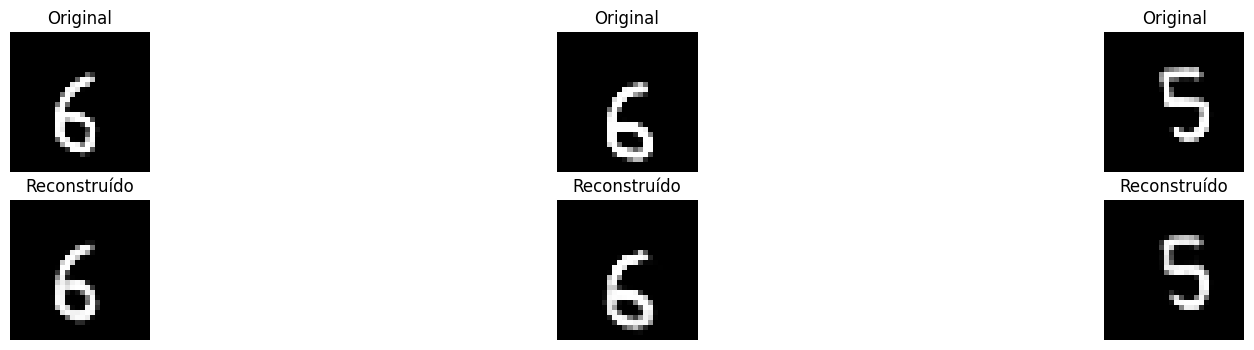

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

input_dim = 784
latent_dim = 10          # Alterar depois (pedido na alínea c)

# Encoder
input_img = layers.Input(shape=(input_dim,))
e = layers.Dense(512, activation='relu')(input_img)
e = layers.Dense(256, activation='relu')(e)
latent = layers.Dense(latent_dim, activation='linear', name="latent_space")(e)

# Decoder
d = layers.Dense(256, activation='relu')(latent)
d = layers.Dense(512, activation='relu')(d)
output = layers.Dense(input_dim, activation='sigmoid')(d)

# Autoencoder
autoencoder = models.Model(input_img, output)

# Encoder separado (para extrair representações latentes)
encoder = models.Model(input_img, latent)

# Decoder separado
latent_input = layers.Input(shape=(latent_dim,))
decoder_layer1 = autoencoder.layers[-3](latent_input)
decoder_layer2 = autoencoder.layers[-2](decoder_layer1)
decoder_layer3 = autoencoder.layers[-1](decoder_layer2)
decoder = models.Model(latent_input, decoder_layer3)

autoencoder.compile(optimizer='adam', loss='mse')

# Mostrar arquitetura
autoencoder.summary()

# Normalização
X_scaled = X / 255.0

# Treino
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=256,
    shuffle=True
)

# Reconstruções
n = 3
plt.figure(figsize=(20, 4))

# Mostrar originais
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_scaled[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstrução
    ax = plt.subplot(2, n, i + 1 + n)
    pred = autoencoder.predict(X_scaled[i:i+1])
    plt.imshow(pred.reshape(28, 28), cmap='gray')
    plt.title("Reconstruído")
    plt.axis("off")

plt.show()

Foi implementado um autoencoder totalmente conectado com o objetivo de aprender uma representação compacta das imagens do dataset MNIST. As imagens são inicialmente convertidas em vetores unidimensionais de dimensão 784 e normalizadas para o intervalo [0, 1].

O encoder é composto por duas camadas Dense com 512 e 256 neurónios, respetivamente, utilizando a função de ativação ReLU, seguidas de uma camada linear que define o espaço latente com dimensão fixa (latent_dim = 10). Esta camada central fornece a representação comprimida dos dados.

O decoder reconstrói a imagem original a partir do código latente, recorrendo a uma arquitetura simétrica ao encoder, terminando numa camada de saída com ativação sigmoide. O modelo é treinado de forma não supervisionada utilizando o otimizador Adam e a função de perda Mean Squared Error (MSE).

Após o treino, a qualidade do modelo é avaliada visualmente através da comparação entre imagens originais e as respetivas reconstruções, permitindo verificar a capacidade do autoencoder em preservar a estrutura essencial dos dígitos apesar da compressão imposta.

# **Otimização conjunta (DCN) com K-Means**

---



`Extração de características latentes`

In [ ]:
latents = encoder.predict(X_scaled, batch_size=256)
print("Latent shape:", latents.shape)

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Latent shape: (107730, 10)


Este bloco utiliza o encoder treinado para transformar as imagens normalizadas (X_scaled) em vetores no espaço latente. O comando **encoder.predict(...)** gera a matriz latents, onde cada linha corresponde à representação comprimida de uma imagem. O print confirma a dimensão do output, ou seja, o número de amostras e o tamanho do código latente.

`DCN com K-Means`

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 10  # O dataset tem 10 números, logo tem 10 classes
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
kmeans_labels = kmeans.fit_predict(latents)

print("Clusters encontrados pelo K-Means:", np.unique(kmeans_labels))

Clusters encontrados pelo K-Means: [0 1 2 3 4 5 6 7 8 9]


Aqui aplica-se o K-Means diretamente sobre as representações latentes obtidas no bloco anterior. Define-se **n_clusters = 10**, coerente com o número de classes do MNIST (dígitos 0-9). O método fit_predict devolve a atribuição de cluster para cada amostra (kmeans_labels) e imprime-se o conjunto de clusters encontrados, permitindo validar que o algoritmo está a gerar etiquetas.

In [ ]:
latent_layer = autoencoder.get_layer("latent_space").output

dcn_model = models.Model(
    inputs=autoencoder.input,
    outputs=[autoencoder.output, latent_layer]
)

Este bloco cria um modelo do tipo Deep Clustering Network (DCN) ao acoplar a reconstrução do autoencoder com o vetor latente. A camada latent_space é extraída do autoencoder e o novo dcn_model passa a devolver duas saídas:
*   A reconstrução da imagem
*   A representação latente

Isto prepara o modelo para uma otimização conjunta entre reconstrução e clustering.

In [ ]:
# Latentes antes do DCN (antes de alterar o encoder)
latents_before = encoder.predict(X_scaled, batch_size=256)

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Antes de iniciar o treino conjunto (DCN), este bloco guarda as representações latentes iniciais (latents_before). Isto serve como referência (“antes”) para comparar posteriormente com o espaço latente após otimização conjunta (“depois”), tanto em termos de clustering como visualmente (UMAP).

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

lambda_cluster = 0.1  # Peso da loss de clustering

# Combined output para o DCN
latent_layer = autoencoder.get_layer("latent_space").output
combined_output = layers.Concatenate()([autoencoder.output, latent_layer])

# Modelo DCN
full_dcn = models.Model(inputs=autoencoder.input, outputs=combined_output)

def dcn_loss(y_true, y_pred):
    x_true = y_true[:, :784]
    centroid_target = y_true[:, 784:]

    x_pred = y_pred[:, :784]
    z_pred = y_pred[:, 784:]

    recon_loss = tf.reduce_mean(tf.square(x_true - x_pred))
    cluster_loss = tf.reduce_mean(tf.square(z_pred - centroid_target))

    return recon_loss + lambda_cluster * cluster_loss

full_dcn.compile(optimizer='adam', loss=dcn_loss)

# Loop DCN
max_epochs = 20
prev_labels = None

for epoch in range(max_epochs):
    print(f"\nDCN Epoch {epoch+1}")

    latents = encoder.predict(X_scaled, batch_size=256)

    kmeans = KMeans(n_clusters=10, n_init=20)
    labels = kmeans.fit_predict(latents)
    centroids = kmeans.cluster_centers_
    centroid_targets = centroids[labels]

    if prev_labels is not None and np.array_equal(labels, prev_labels):
        break

    prev_labels = labels.copy()

    y_true = np.concatenate([X_scaled, centroid_targets], axis=1)

    full_dcn.fit(
        X_scaled, y_true,
        epochs=1,
        batch_size=256,
        shuffle=True,
        verbose=1
    )


DCN Epoch 1
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.7252

DCN Epoch 2
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3784

DCN Epoch 3
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2350

DCN Epoch 4
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1688

DCN Epoch 5
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1326

DCN Epoch 6
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1104

DCN Epoch 7
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0937

DCN Epoch 8
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0802

DCN Epoch 9
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0734

DCN Epoch

Neste bloco implementa-se o treino iterativo do DCN. Primeiro define-se uma função de perda combinada (dcn_loss) composta por duas parcelas:
*   Erro de reconstrução (diferença entre imagem original e reconstruída),
*   Erro de clustering (diferença entre o vetor latente previsto e o centróide associado pelo K-Means).

A cada época do loop: calculam-se latentes atuais com o encoder e

*   Corre-se K-Means e calculam-se centróides,
*   Associa-se cada amostra ao seu centróide (centroid_targets),
*   Treina-se o modelo uma época com targets concatenados (imagem + centróide).

O processo repete-se até estabilização das atribuições (quando os labels deixam de mudar entre épocas) ou até ao máximo de épocas definido.

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


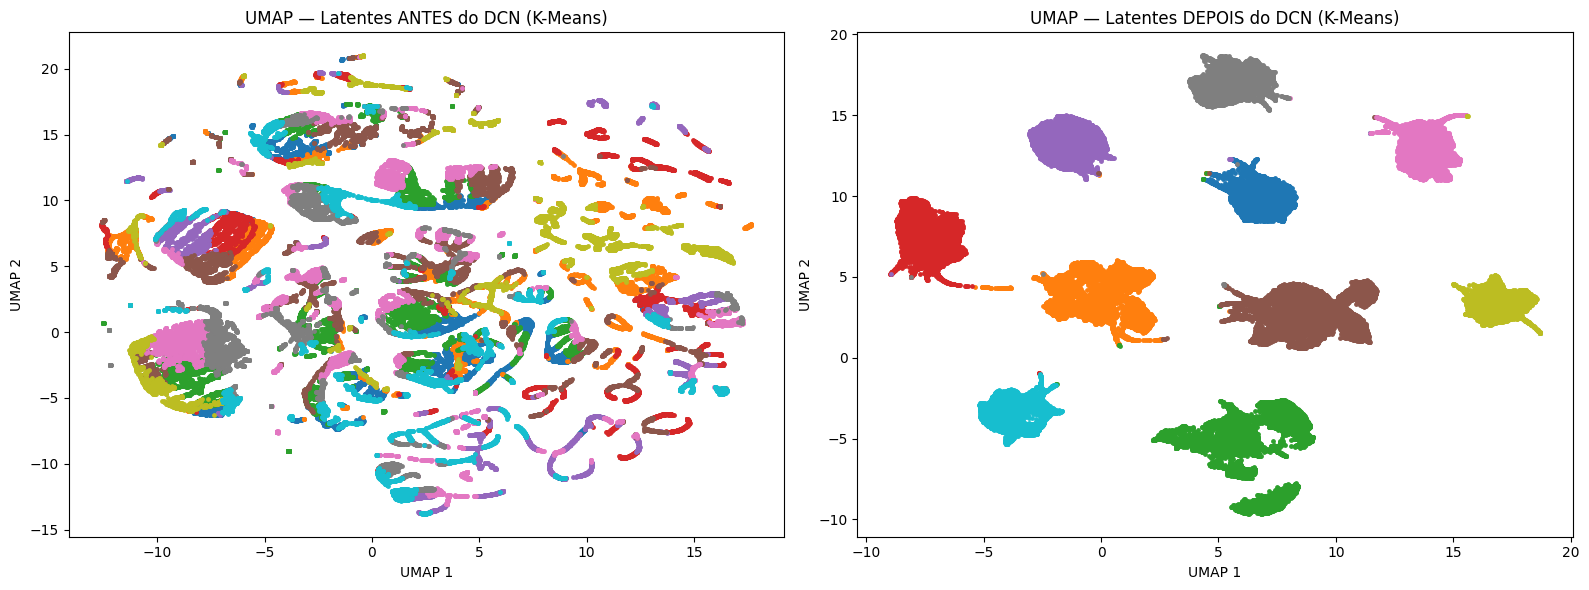

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import umap.umap_ as umap
from sklearn.cluster import KMeans

# Latentes depois do DCN
latents_after = encoder.predict(X_scaled, batch_size=256)

# Clustering antes e depois
labels_before = KMeans(n_clusters=10, n_init=20).fit_predict(latents_before)
labels_after = KMeans(n_clusters=10, n_init=20).fit_predict(latents_after)

# UMAP antes
umap_before = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, random_state=42
).fit_transform(latents_before)

# UMAP depois
umap_after = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, random_state=42
).fit_transform(latents_after)

plt.figure(figsize=(16, 6))

# Antes
plt.subplot(1, 2, 1)
for cid in np.unique(labels_before):
    mask = labels_before == cid
    plt.scatter(umap_before[mask, 0], umap_before[mask, 1], s=6)
plt.title("UMAP — Latentes ANTES do DCN (K-Means)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Depois
plt.subplot(1, 2, 2)
for cid in np.unique(labels_after):
    mask = labels_after == cid
    plt.scatter(umap_after[mask, 0], umap_after[mask, 1], s=6)
plt.title("UMAP — Latentes DEPOIS do DCN (K-Means)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

A Figura apresenta a projeção UMAP do espaço latente antes e depois da otimização conjunta DCN com K-Means. No estado inicial (à esquerda), correspondente ao autoencoder treinado exclusivamente com a loss de reconstrução, observa-se uma estrutura altamente fragmentada e difusa. Embora existam regiões de maior densidade, os clusters encontram-se sobrepostos e alongados, refletindo o facto do espaço latente ter sido otimizado apenas para preservar informação de reconstrução, sem qualquer incentivo explícito à separação entre classes.

Após a aplicação do Deep Clustering Network (à direita), verifica-se uma reorganização profunda do espaço latente. Os dados passam a agrupar-se em regiões compactas, bem delimitadas e claramente separadas, evidenciando o efeito da introdução da componente de clustering na função de custo. Esta transformação demonstra que o DCN consegue alinhar a aprendizagem das representações latentes com a estrutura inerente dos dados, promovendo simultaneamente boa reconstrução e elevada separabilidade entre clusters.

A comparação visual entre os dois estados confirma que a otimização conjunta AE-K-Means conduz a um espaço latente semanticamente mais significativo, no qual as representações codificadas são não apenas compactas, mas também adequadas para tarefas de clustering não supervisionado.

# **Otimização conjunta (DCN) com DBSCAN**

---

`Extração de características latentes`

In [ ]:
# Latentes ANTES do DCN
latents_before = encoder.predict(X_scaled, batch_size=256)
print("Latent shape:", latents_before.shape)

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Latent shape: (107730, 10)


Tal como no K-Means, este código procura transformar as imagens normalizadas (X_scaled) em vetores no espaço latente.

`Método do cotovelo`

Epsilon estimado: 0.8798


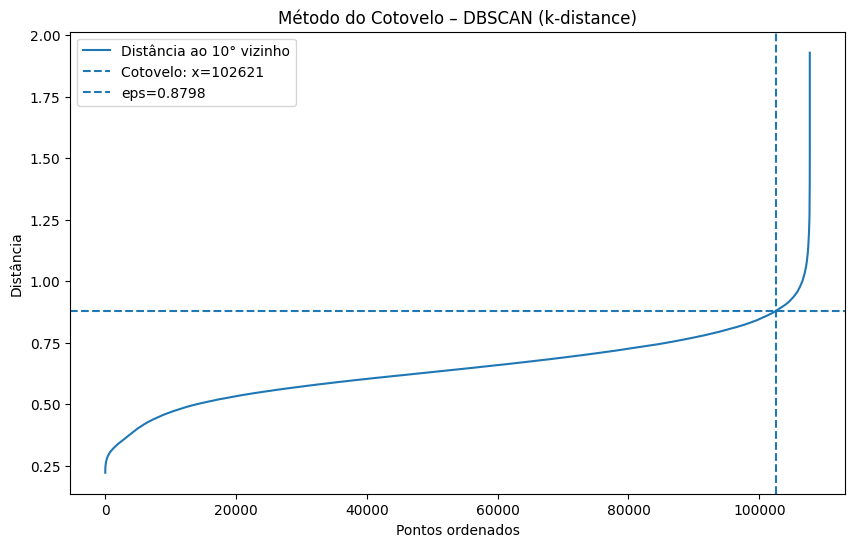

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

min_samples = 10
k = min_samples

# Normalizar latentes
scaler_dbscan = StandardScaler()
latents_before_std = scaler_dbscan.fit_transform(latents_before)

neighbors = NearestNeighbors(n_neighbors=k).fit(latents_before_std)
distances, _ = neighbors.kneighbors(latents_before_std)

k_distances = np.sort(distances[:, -1])

# Método do cotovelo
x = np.arange(len(k_distances))
p1 = np.array([0.0, float(k_distances[0])])
p2 = np.array([float(len(k_distances)-1), float(k_distances[-1])])

v = p2 - p1
pts = np.vstack([x, k_distances]).T - p1
dist_to_line = np.abs(v[0]*pts[:, 1] - v[1]*pts[:, 0]) / np.linalg.norm(v)

elbow_idx = int(np.argmax(dist_to_line))
eps_estimate = float(k_distances[elbow_idx])

print(f"Epsilon estimado: {eps_estimate:.4f}")

# Gráfico com legendas
plt.figure(figsize=(10, 6))
plt.plot(k_distances, label=f"Distância ao {k}° vizinho")

plt.axvline(elbow_idx, linestyle="--", label=f"Cotovelo: x={elbow_idx}")
plt.axhline(eps_estimate, linestyle="--", label=f"eps={eps_estimate:.4f}")

plt.title("Método do Cotovelo – DBSCAN (k-distance)")
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância")
plt.legend()
plt.show()

O método do cotovelo foi usado aqui para saber o valor de epsilon, que determina o raio de distância a que um ponto pode ser considerado vizinho do outro para poder assim formar os clusters. Através da análise das distâncias ao k-ésimo vizinho mais próximo, constrói-se a curva k-distance, e o ponto onde ocorre a maior “quebra” (cotovelo) é escolhido como eps. Este valor estima o limite onde a densidade começa a separar clusters reais de ruído.

O gráfico final mostra o ponto do cotovelo e o valor de eps escolhido.

`DBSCAN antes do DCN`



In [ ]:
from sklearn.cluster import DBSCAN

eps = eps_estimate

dbscan_before = DBSCAN(eps=eps, min_samples=min_samples)
labels_before_db = dbscan_before.fit_predict(latents_before_std)

print("Clusters encontrados:", len(np.unique(labels_before_db[labels_before_db != -1])))
print("Noise:", int(np.sum(labels_before_db == -1)))

Clusters encontrados: 25
Noise: 876


Este bloco aplica o algoritmo DBSCAN diretamente sobre os vetores latentes originais, usando o valor de eps obtido anteriormente. O objetivo é observar quantos clusters o DBSCAN encontra antes de qualquer treino do modelo DCN. Também é contabilizado o número de pontos classificados como noise, permitindo avaliar a separabilidade da representação latente inicial.

`Modelo DCN + treino`

In [ ]:
import numpy as np

unique = [c for c in np.unique(labels_before_db) if c != -1]
centers = {}

for c in unique:
    mask = labels_before_db == c
    centers[c] = latents_before[mask].mean(axis=0)

Neste bloco, após aplicar o DBSCAN aos vetores latentes, são calculados os centróides de cada cluster. Para isso, todos os pontos pertencentes ao mesmo rótulo são agrupados e é feita a média das suas representações latentes, obtendo assim um vetor que resume a posição média do cluster no espaço. Estes centróides serão usados como objetivos (“targets”) durante o treino, permitindo orientar o modelo para aproximar as representações latentes de cada ponto ao respetivo centroide.

In [ ]:
targets = np.zeros_like(latents_before)

for i, l in enumerate(labels_before_db):
    if l == -1:
        targets[i] = latents_before[i]      # noise → mantém
    else:
        targets[i] = centers[l]             # cluster → puxa para centro

Depois de calcular os centróides, este bloco atribui a cada ponto o centróide correspondente ao cluster onde pertence. Caso seja ruído (label = –1), mantém-se o ponto inalterado ou ignora-se, dependendo do método. Isto produz um conjunto de pseudo-targets que indicam para onde cada representação latente deve mover-se durante o treino. Este passo é essencial porque transforma o clustering em informação diferenciável que pode ser usada no gradiente.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

latent_layer = autoencoder.get_layer("latent_space").output
combined_output = layers.Concatenate()([autoencoder.output, latent_layer])

dcn_model = models.Model(autoencoder.input, combined_output)
optimizer = tf.keras.optimizers.Adam(1e-4)

batch_size = 256
lambda_cluster = 0.1

Aqui é construído o modelo DCN propriamente dito, que combina a saída normal do autoencoder (a reconstrução) com a sua representação latente. A ideia é que o modelo continue a aprender a reconstruir corretamente os dados, mas também aprenda embeddings mais coesos e estruturados graças ao termo da loss do clustering. O concatenar da saída reconstruída com o espaço latente num único modelo permite calcular gradientes para ambos os objetivos numa única passagem.

In [ ]:
epochs = 3
n = len(X_scaled)

for epoch in range(epochs):
    print(f"\nTreino DCN epoch {epoch+1}/{epochs}")

    for i in range(n // batch_size):
        x_b = X_scaled[i*batch_size:(i+1)*batch_size]
        c_b = targets[i*batch_size:(i+1)*batch_size]

        with tf.GradientTape() as tape:
            out = dcn_model(x_b, training=True)
            x_pred = out[:, :784]
            z_pred = out[:, 784:]

            loss_recon = tf.reduce_mean(tf.square(x_b - x_pred))
            loss_cluster = tf.reduce_mean(tf.square(z_pred - c_b))
            loss = loss_recon + lambda_cluster * loss_cluster

        grads = tape.gradient(loss, dcn_model.trainable_weights)
        optimizer.apply_gradients(zip(grads, dcn_model.trainable_weights))

    print(f"loss_recon={float(loss_recon):.4f}  loss_cluster={float(loss_cluster):.4f}")


Treino DCN epoch 1/3
loss_recon=0.0313  loss_cluster=11.2984

Treino DCN epoch 2/3
loss_recon=0.0395  loss_cluster=6.7053

Treino DCN epoch 3/3
loss_recon=0.0409  loss_cluster=4.8539


O loop de treino realiza várias épocas onde, em cada uma, o modelo ajusta os pesos para reduzir simultaneamente o erro de reconstrução e o erro de clusterização. Em cada batch, o DCN calcula a reconstrução da imagem e a representação latente; depois, mede-se a distância dessa representação ao centróide do cluster, e os dois termos são combinados numa loss conjunta. O gradiente desta loss é então aplicado para mover o embedding de cada ponto na direção do centróide, ao mesmo tempo que mantém a qualidade da reconstrução. A cada época, espera-se que o cluster loss diminua.

`DBSCAN depois do DCN`

In [ ]:
latents_after = encoder.predict(X_scaled, batch_size=256)
dbscan_after = DBSCAN(eps=eps_estimate, min_samples=10)
labels_after_db = dbscan_after.fit_predict(latents_after)

print("Clusters depois:", len(np.unique(labels_after_db[labels_after_db != -1])))
print("Noise depois:", int(np.sum(labels_after_db == -1)))

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Clusters depois: 26
Noise depois: 106858


Este bloco volta a aplicar o DBSCAN após o treino do DCN, agora sobre o espaço latente atualizado. O objetivo é comparar o número de clusters e a quantidade de ruído antes e depois do processo, permitindo avaliar se o DCN conseguiu organizar melhor os dados no espaço latente e melhorar a estrutura dos clusters.

`Gráficos`

In [ ]:
latents_after = encoder.predict(X_scaled, batch_size=256, verbose=0)
latents_after_std = scaler_dbscan.transform(latents_after)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


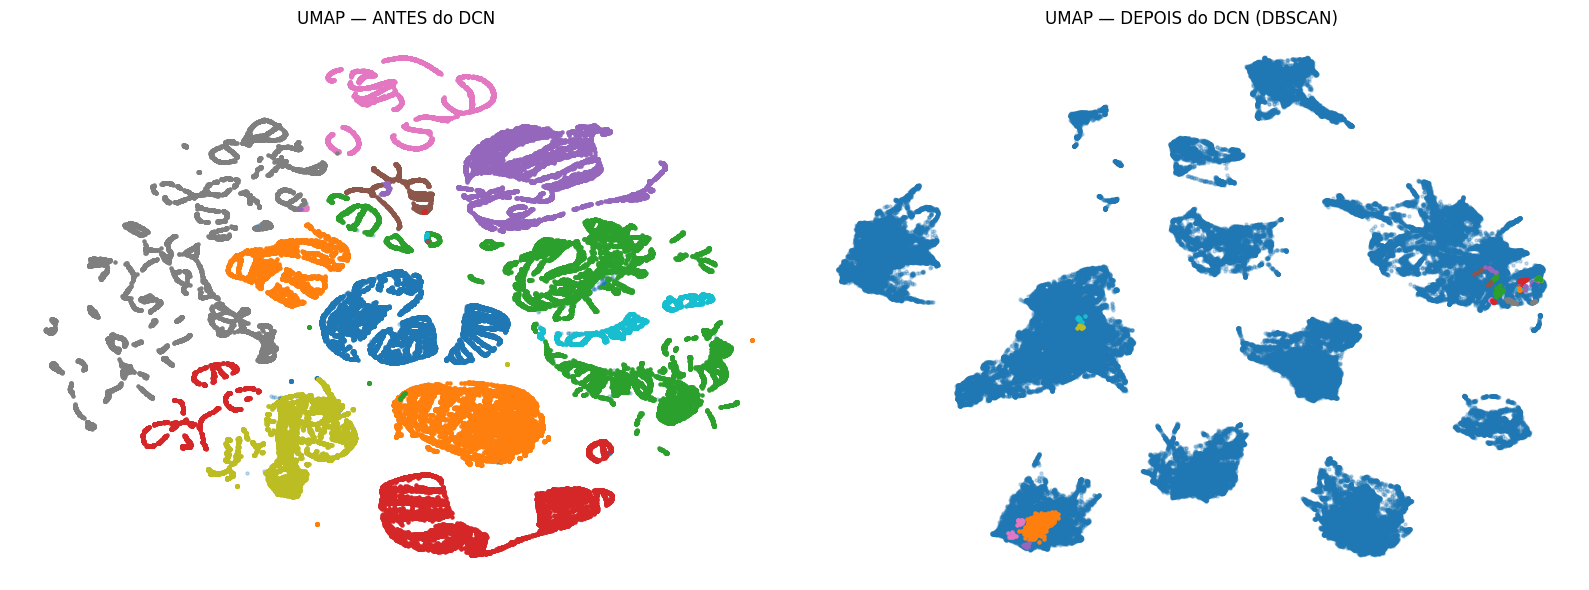

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np

umap_before = umap.UMAP(
    n_neighbors=15, min_dist=0.1, random_state=42
).fit_transform(latents_before_std)

umap_after = umap.UMAP(
    n_neighbors=15, min_dist=0.1, random_state=42
).fit_transform(latents_after_std)

plt.figure(figsize=(16, 6))

# Antes
plt.subplot(1, 2, 1)
for cid in np.unique(labels_before_db):
    m = labels_before_db == cid
    plt.scatter(
        umap_before[m, 0],
        umap_before[m, 1],
        s=5,
        alpha=0.25 if cid == -1 else 1.0
    )
plt.title("UMAP — ANTES do DCN ")
plt.axis("off")

# Depois
plt.subplot(1, 2, 2)
for cid in np.unique(labels_after_db):
    m = labels_after_db == cid
    plt.scatter(
        umap_after[m, 0],
        umap_after[m, 1],
        s=5,
        alpha=0.25 if cid == -1 else 1.0
    )
plt.title("UMAP — DEPOIS do DCN (DBSCAN)")
plt.axis("off")

plt.tight_layout()
plt.show()

A figura apresenta a projeção UMAP das representações latentes antes e depois da aplicação do Deep Clustering Network (DCN) com DBSCAN. No gráfico da esquerda (antes do DCN), observa-se que as representações latentes do autoencoder já apresentam alguma estrutura, com grupos relativamente compactos e bem distribuídos, correspondendo a diferentes padrões nos dados. No entanto, existe ainda alguma sobreposição entre clusters e fronteiras pouco definidas entre grupos próximos.

Após a aplicação do DCN (gráfico da direita), verifica-se uma reorganização clara do espaço latente. O DBSCAN identifica vários grupos densos bem separados, enquanto uma grande parte dos pontos é classificada como noise, representada a azul. Estes pontos noise correspondem a amostras que não pertencem a regiões de alta densidade e que, segundo o DBSCAN, não cumprem os critérios para formar um cluster estável. A presença significativa de noise é esperada neste método, especialmente quando aplicado a representações latentes de elevada complexidade.

Comparando ambos os gráficos, conclui-se que o DCN contribui para uma maior separação entre regiões densas do espaço latente, reforçando a coesão interna dos clusters detetados pelo DBSCAN. Embora muitos pontos sejam classificados como noise, os clusters formados após o DCN apresentam-se mais compactos e isolados, indicando que a otimização conjunta entre o autoencoder e o algoritmo de clustering melhora a estrutura global do espaço latente.

# **Variação da dimensão latente**

---



`Autoencoder`

In [ ]:
# garantir tipo correto
X = X.astype(np.float32)

# normalização para [0, 1]
X_scaled = X / 255.0

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (107730, 784)


Neste bloco, os dados de entrada são convertidos para o tipo float32, garantindo compatibilidade e eficiência computacional durante o treino da rede neuronal. Em seguida, os valores dos píxeis são normalizados para o intervalo [0,1], dividindo por 255.

Esta normalização é fundamental para estabilizar o processo de otimização do autoencoder, uma vez que as funções de ativação (nomeadamente a sigmoide na camada de saída) assumem valores nesse intervalo.

In [ ]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

def build_autoencoder(latent_dim):
    # Encoder
    encoder_input = layers.Input(shape=(784,))
    x = layers.Dense(512, activation="relu")(encoder_input)
    x = layers.Dense(256, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="linear", name="latent_space")(x)

    encoder = models.Model(encoder_input, latent)

    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(256, activation="relu")(decoder_input)
    x = layers.Dense(512, activation="relu")(x)
    decoder_output = layers.Dense(784, activation="sigmoid")(x)

    decoder = models.Model(decoder_input, decoder_output)

    # Autoencoder completo
    autoencoder_input = layers.Input(shape=(784,))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)

    autoencoder = models.Model(autoencoder_input, decoded)
    autoencoder.compile(optimizer="adam", loss="mse")

    return autoencoder, encoder, decoder


def train_ae_for_latent_dim(latent_dim, X_scaled, epochs=30):
    print(f"\nTreino AE com latent_dim = {latent_dim}")

    autoencoder, encoder, decoder = build_autoencoder(latent_dim)

    # Treino
    history = autoencoder.fit(
        X_scaled, X_scaled,
        epochs=epochs,
        batch_size=256,
        shuffle=True,
        verbose=1
    )

    # Gráficos das reconstruções
    n = 3
    idxs = np.random.choice(len(X_scaled), n, replace=False)

    plt.figure(figsize=(20, 4))

    for i, idx in enumerate(idxs):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(X_scaled[idx].reshape(28, 28), cmap="gray")
        plt.title(f"Original")
        plt.axis("off")

        # Reconstrução
        ax = plt.subplot(2, n, i + 1 + n)
        pred = autoencoder.predict(X_scaled[idx:idx+1])
        plt.imshow(pred.reshape(28, 28), cmap="gray")
        plt.title("Reconstruído")
        plt.axis("off")

    plt.suptitle(f"Reconstruções — latent_dim = {latent_dim}")
    plt.show()

    return encoder, history.history["loss"]

Aqui é definida a arquitetura do autoencoder totalmente conectado (Dense).
O encoder comprime o vetor de entrada de 784 dimensões através de camadas sucessivas até ao espaço latente, cuja dimensão é controlada pelo parâmetro **latent_dim**.

O decoder realiza o processo inverso, reconstruindo a imagem original a partir da representação latente.

O modelo completo é compilado utilizando o otimizador Adam e a função de perda MSE (erro quadrático médio), adequada para tarefas de reconstrução.

`Treino`


Treino AE com latent_dim = 5
Epoch 1/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0638
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0233
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0184
Epoch 4/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0161
Epoch 5/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0147
Epoch 6/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0135
Epoch 7/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0127
Epoch 8/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0119
Epoch 9/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0113
Epoch 10/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0107
Epoch 11/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0102
Epoch 12/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0098
Epoch 13/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094
Epoch 14/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0091
Epoch 15/30
421/421 ━━━━━━━

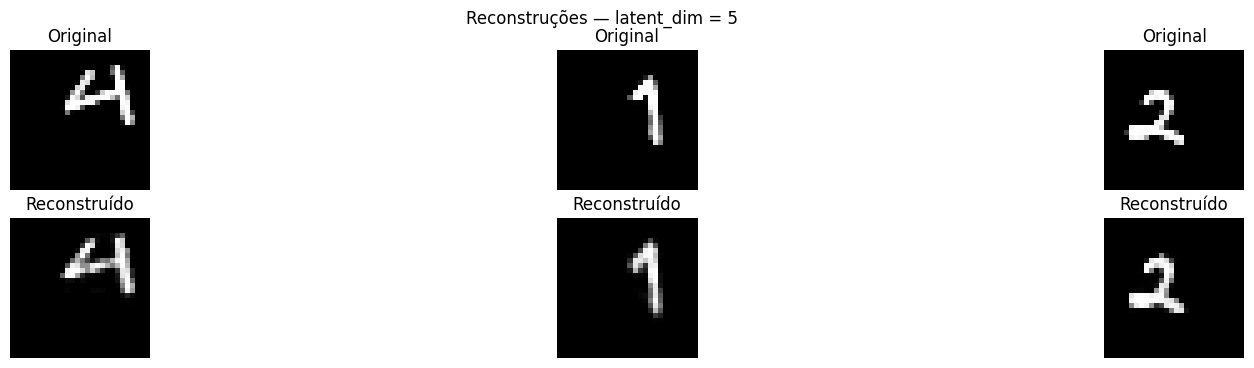


Treino AE com latent_dim = 10
Epoch 1/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0629
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0164
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0101
Epoch 4/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0079
Epoch 5/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0068
Epoch 6/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060
Epoch 7/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054
Epoch 8/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0050
Epoch 9/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046
Epoch 10/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044
Epoch 11/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0041
Epoch 12/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0039
Epoch 13/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0037
Epoch 14/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036
Epoch 15/30
421/421 ━━━━━━

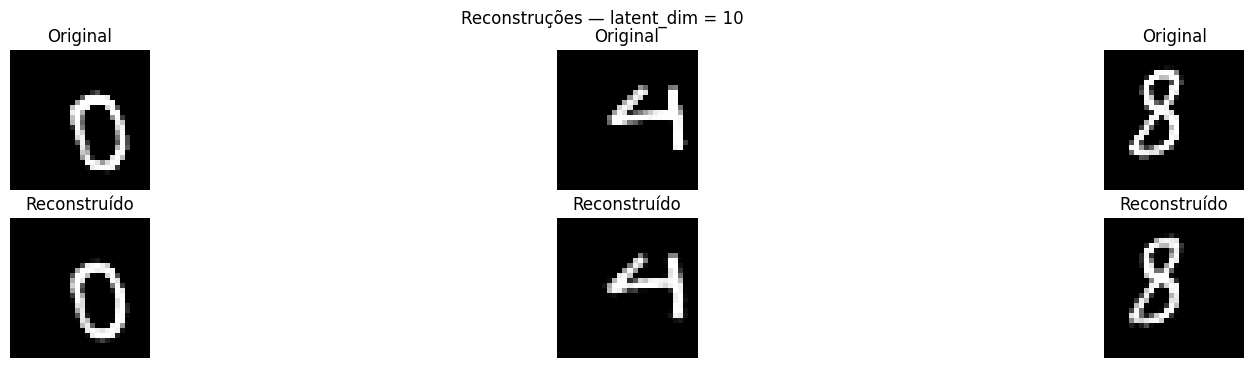


Treino AE com latent_dim = 20
Epoch 1/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0606
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0208
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0112
Epoch 4/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0073
Epoch 5/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058
Epoch 6/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048
Epoch 7/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042
Epoch 8/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0038
Epoch 9/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035
Epoch 10/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0031
Epoch 11/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0029
Epoch 12/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0028
Epoch 13/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026
Epoch 14/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024
Epoch 15/30
421/421 ━━━━━━

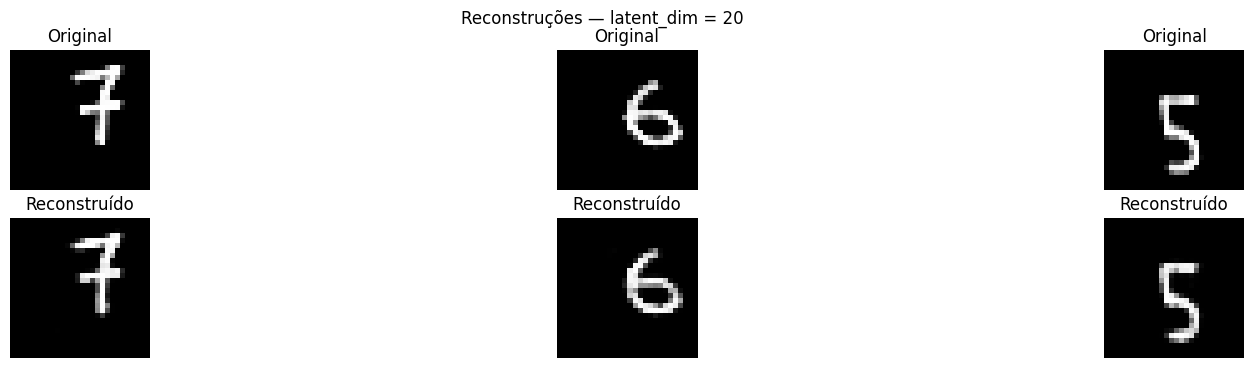


Treino AE com latent_dim = 30
Epoch 1/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0614
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0221
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134
Epoch 4/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0086
Epoch 5/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062
Epoch 6/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0050
Epoch 7/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0040
Epoch 8/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035
Epoch 9/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0031
Epoch 10/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0027
Epoch 11/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0025
Epoch 12/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0023
Epoch 13/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022
Epoch 14/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0020
Epoch 15/30
421/421 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


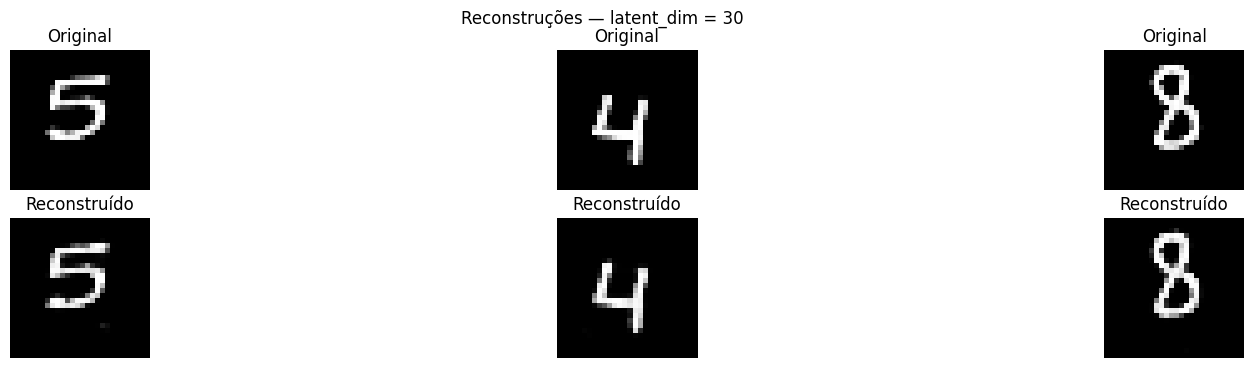

In [ ]:
encoders = {}
errors = {}

latent_dims = [5, 10, 20, 30]

for ld in latent_dims:
    enc, loss = train_ae_for_latent_dim(ld, X_scaled)
    encoders[ld] = enc
    errors[ld] = loss

Neste bloco, o autoencoder é treinado de forma não supervisionada, utilizando as próprias imagens como entrada e alvo. Após o treino, são selecionadas aleatoriamente algumas amostras do conjunto de dados para visualizar a qualidade das reconstruções.

A comparação entre imagens originais e reconstruídas permite avaliar qualitativamente a capacidade do espaço latente em preservar as características essenciais dos dados.

Depois, o autoencoder é treinado repetidamente para diferentes valores da dimensão do espaço latente (latent_dims = [5, 10, 20, 30]).
Para cada configuração, é guardado o encoder treinado e o histórico da função de perda. Esta abordagem permite analisar o impacto da dimensionalidade latente na capacidade de reconstrução do modelo, fornecendo uma base para comparar desempenho e complexidade do espaço latente.

`Gráficos`

3367/3367 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


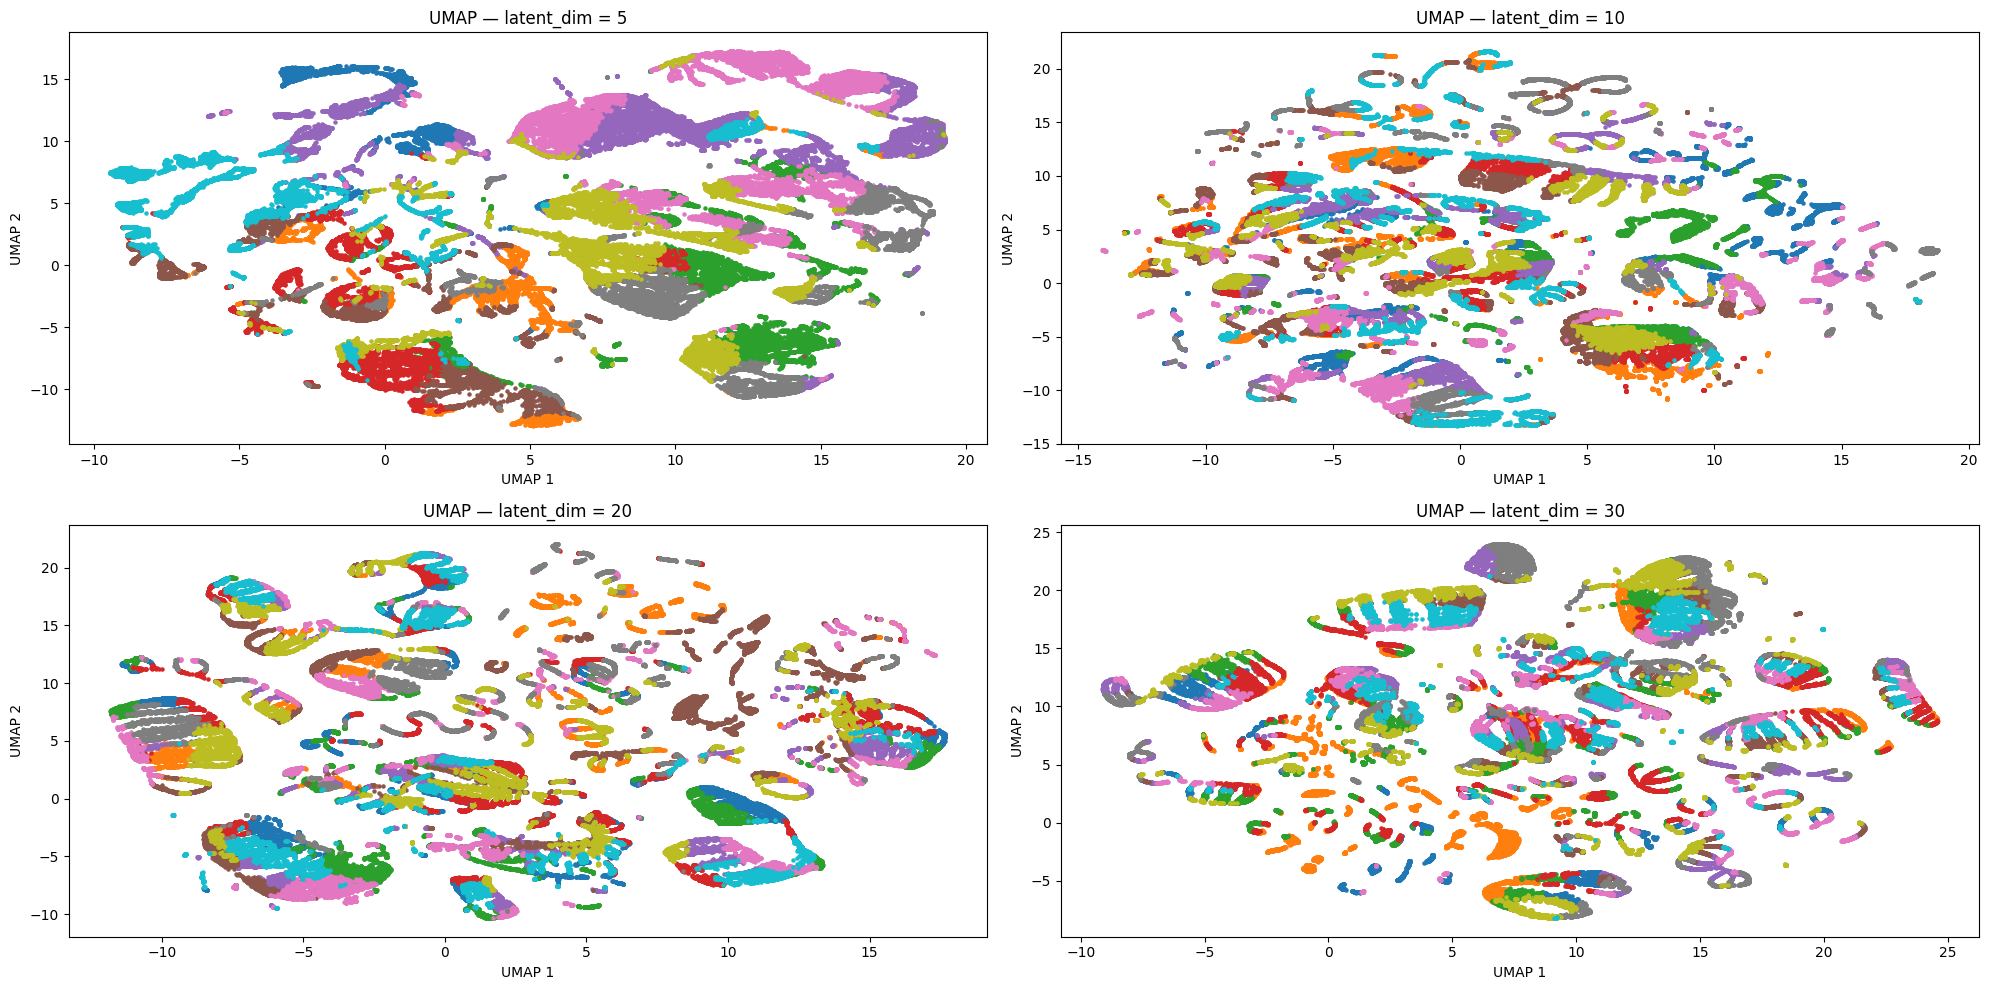

In [ ]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.cluster import KMeans
import numpy as np

plt.figure(figsize=(20, 10))

for i, ld in enumerate(latent_dims):
    encoder = encoders[ld]

    # Obter latentes
    lat = encoder.predict(X_scaled)

    # K-Means para visualização
    km = KMeans(n_clusters=10, n_init=20)
    labels = km.fit_predict(lat)

    # Redução
    lat_2d = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean"
    ).fit_transform(lat)

    plt.subplot(2, 2, i+1)
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        plt.scatter(lat_2d[mask, 0], lat_2d[mask, 1], s=5, label=str(cluster_id))
    plt.title(f"UMAP — latent_dim = {ld}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

A variação da dimensionalidade do espaço latente (**latent_dim**) demonstra o equilíbrio necessário para um agrupamento de dados (**clusters**) eficaz.

Com dimensões muito baixas (**latent_dim=5**), o Autoencoder é forçado a uma compressão excessiva, o que leva à perda de informação discriminativa e resulta em clusters altamente dispersos e malformados. Por outro lado, aumentar a dimensão para **latent_dim=20** ou **latent_dim=30** oferece mais capacidade de codificação, mas não traduz essa redundância numa melhor separação de clusters, pois o espaço latente continua difuso.

A dimensão **latent_dim=10**, que corresponde ao número de classes (dígitos), oferece o compromisso mais eficaz entre a compressão e a retenção de features essenciais, estabelecendo uma base ideal para a otimização subsequente do clustering DCN.

# **Diferentes pesos para a reconstrução e clustering**

---



`Funções importantes`

**Loss do DCN**

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

def dcn_loss(lambda_cluster):
    def loss(y_true, y_pred):
        x_true = y_true[:, :784]
        z_target = y_true[:, 784:]

        x_pred = y_pred[:, :784]
        z_pred = y_pred[:, 784:]

        recon = tf.reduce_mean(tf.square(x_true - x_pred))
        cluster = tf.reduce_mean(tf.square(z_pred - z_target))

        return recon + lambda_cluster * cluster
    return loss

Este bloco define a função de custo utilizada no Deep Clustering Network (DCN).
A loss é composta por duas componentes: a loss de reconstrução, que mede o erro entre a entrada original e a sua reconstrução pelo autoencoder, e a loss de clustering, que mede a distância entre a representação latente e o centróide do cluster atribuído.
O parâmetro **lambda_cluster** controla o peso relativo da componente de clustering face à reconstrução, permitindo estudar a relação entre a qualidade de reconstrução e a estruturação do espaço latente.

**Construção do DCN (Autoencoder + Encoder concatenados)**

In [ ]:
from tensorflow.keras import layers, models

def build_dcn(autoencoder, encoder):
    inp = autoencoder.input
    x_recon = autoencoder.output
    z_latent = encoder(inp)

    merged = layers.Concatenate()([x_recon, z_latent])
    model = models.Model(inp, merged)
    return model

Neste bloco, é construído o modelo DCN.

O modelo reutiliza o autoencoder previamente treinado, combinando a sua saída de reconstrução com a representação latente produzida pelo encoder. Estas duas saídas são concatenadas, permitindo que a função de loss tenha acesso simultâneo à reconstrução do input e ao vetor latente, necessário para impor a restrição de clustering durante o treino conjunto.

**Treino do DCN**

In [ ]:
def train_dcn(encoder, autoencoder, X_scaled, lambda_cluster, max_epochs=20):
    print(f"\nTreino DCN para λ={lambda_cluster}")

    dcn_model = build_dcn(autoencoder, encoder)
    dcn_model.compile(optimizer="adam", loss=dcn_loss(lambda_cluster))

    for epoch in range(max_epochs):

        Z = encoder.predict(X_scaled, batch_size=256, verbose=0)

        km = KMeans(n_clusters=10, n_init=20)
        labels = km.fit_predict(Z)
        centroids = km.cluster_centers_
        targets = centroids[labels]

        Y = np.concatenate([X_scaled, targets], axis=1)

        dcn_model.fit(X_scaled, Y, epochs=1, batch_size=256, shuffle=True, verbose=0)

        print(f"Época {epoch+1}/{max_epochs} concluída.")

    return encoder, km

Este bloco implementa o ciclo de treino do DCN. Em cada época, são extraídas as representações latentes atuais e aplicado o algoritmo K-Means para obter novas atribuições de clusters e respetivos centróides. Estes centróides são depois usados como targets para a loss de clustering. O modelo DCN é então treinado durante uma época, atualizando simultaneamente os parâmetros do autoencoder e ajustando o espaço latente de forma a torná-lo mais favorável ao clustering.

**Reconstruções das imagens**

In [ ]:
def plot_reconstructions(autoencoder, X_scaled, lam, n=3):
    idxs = np.random.choice(len(X_scaled), n, replace=False)

    plt.figure(figsize=(20, 4))

    for i, idx in enumerate(idxs):

        ax = plt.subplot(2, n, i + 1)
        plt.imshow(X_scaled[idx].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        pred = autoencoder.predict(X_scaled[idx:idx+1])
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(pred.reshape(28, 28), cmap='gray')
        plt.title(f"Reconstruído (λ={lam})")
        plt.axis("off")

    plt.show()

Este bloco é responsável por visualizar o impacto do treino conjunto na qualidade das reconstruções. São selecionadas aleatoriamente algumas amostras do dataset e comparadas as imagens originais com as suas reconstruções após o treino do DCN. Esta análise permite verificar se o aumento do peso da loss de clustering afeta negativamente a capacidade de reconstrução do autoencoder.

**Gráficos para serem mostrados depois**

In [ ]:
import umap

def compute_umap(encoder, X_scaled):
    Z = encoder.predict(X_scaled)
    reducer = umap.UMAP()
    return reducer.fit_transform(Z)

Esta função calcula uma projeção bidimensional do espaço latente aprendido pelo encoder recorrendo ao algoritmo UMAP. Primeiro, as representações latentes são obtidas através da passagem dos dados normalizados pelo encoder. De seguida, o UMAP é aplicado a essas representações com o objetivo de reduzir a dimensionalidade, preservando a estrutura local dos dados. O resultado é uma projeção em duas dimensões que permite visualizar e analisar a organização dos dados no espaço latente.

`Treino`


Treino DCN para λ=0.01
Época 1/20 concluída.
Época 2/20 concluída.
Época 3/20 concluída.
Época 4/20 concluída.
Época 5/20 concluída.
Época 6/20 concluída.
Época 7/20 concluída.
Época 8/20 concluída.
Época 9/20 concluída.
Época 10/20 concluída.
Época 11/20 concluída.
Época 12/20 concluída.
Época 13/20 concluída.
Época 14/20 concluída.
Época 15/20 concluída.
Época 16/20 concluída.
Época 17/20 concluída.
Época 18/20 concluída.
Época 19/20 concluída.
Época 20/20 concluída.
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


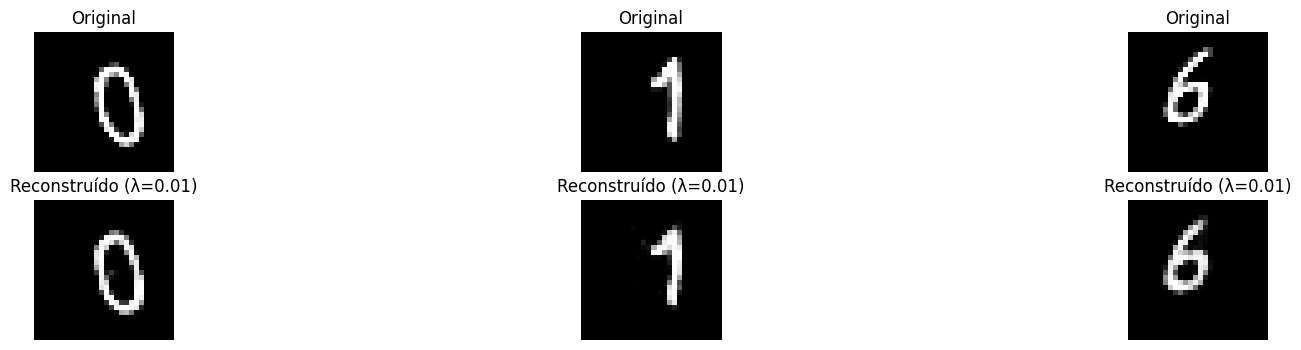


Treino DCN para λ=0.1
Época 1/20 concluída.
Época 2/20 concluída.
Época 3/20 concluída.
Época 4/20 concluída.
Época 5/20 concluída.
Época 6/20 concluída.
Época 7/20 concluída.
Época 8/20 concluída.
Época 9/20 concluída.
Época 10/20 concluída.
Época 11/20 concluída.
Época 12/20 concluída.
Época 13/20 concluída.
Época 14/20 concluída.
Época 15/20 concluída.
Época 16/20 concluída.
Época 17/20 concluída.
Época 18/20 concluída.
Época 19/20 concluída.
Época 20/20 concluída.
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


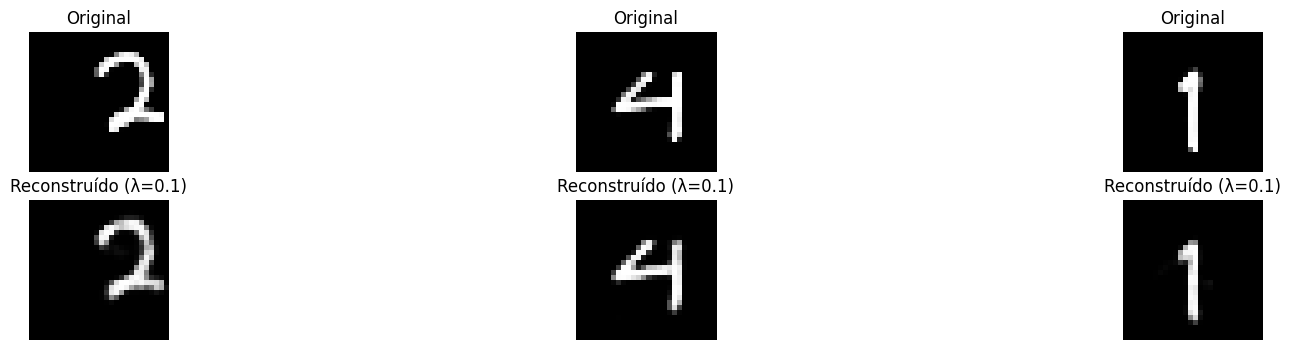


Treino DCN para λ=1.0
Época 1/20 concluída.
Época 2/20 concluída.
Época 3/20 concluída.
Época 4/20 concluída.
Época 5/20 concluída.
Época 6/20 concluída.
Época 7/20 concluída.
Época 8/20 concluída.
Época 9/20 concluída.
Época 10/20 concluída.
Época 11/20 concluída.
Época 12/20 concluída.
Época 13/20 concluída.
Época 14/20 concluída.
Época 15/20 concluída.
Época 16/20 concluída.
Época 17/20 concluída.
Época 18/20 concluída.
Época 19/20 concluída.
Época 20/20 concluída.
3367/3367 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


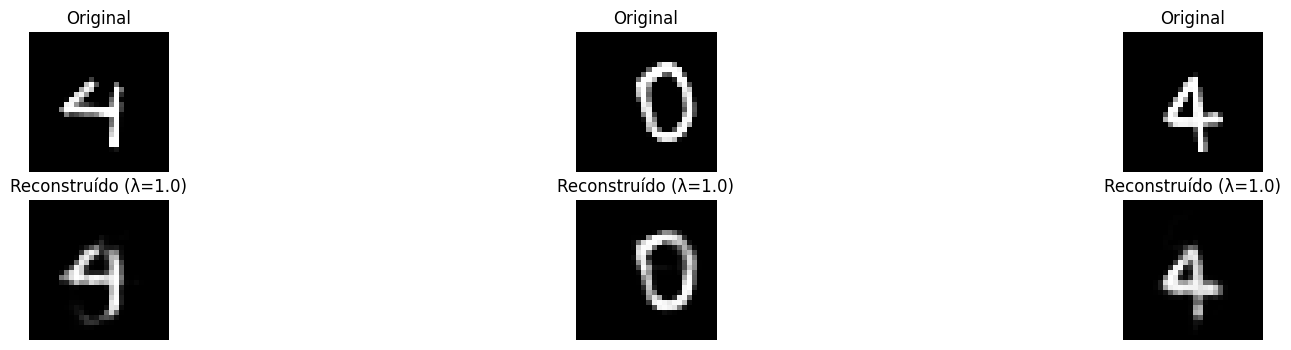

In [ ]:
lambda_values = [0.01, 0.1, 1.0]
results = {}
umap_results = {}

for lam in lambda_values:
    enc_dcn, km = train_dcn(encoder, autoencoder, X_scaled, lam)
    results[lam] = enc_dcn
    umap_results[lam] = compute_umap(enc_dcn, X_scaled)

    plot_reconstructions(autoencoder, X_scaled, lam)

Neste bloco são realizadas experiências para diferentes valores do parâmetro λ, que controla o peso da loss de clustering.
Para cada valor de λ, o DCN é treinado, as reconstruções são visualizadas e o espaço latente resultante é reduzido com UMAP para análise visual. Esta abordagem permite estudar como diferentes equilíbrios entre reconstrução e clustering influenciam tanto a estrutura do espaço latente como a qualidade das reconstruções.

`Gráficos`

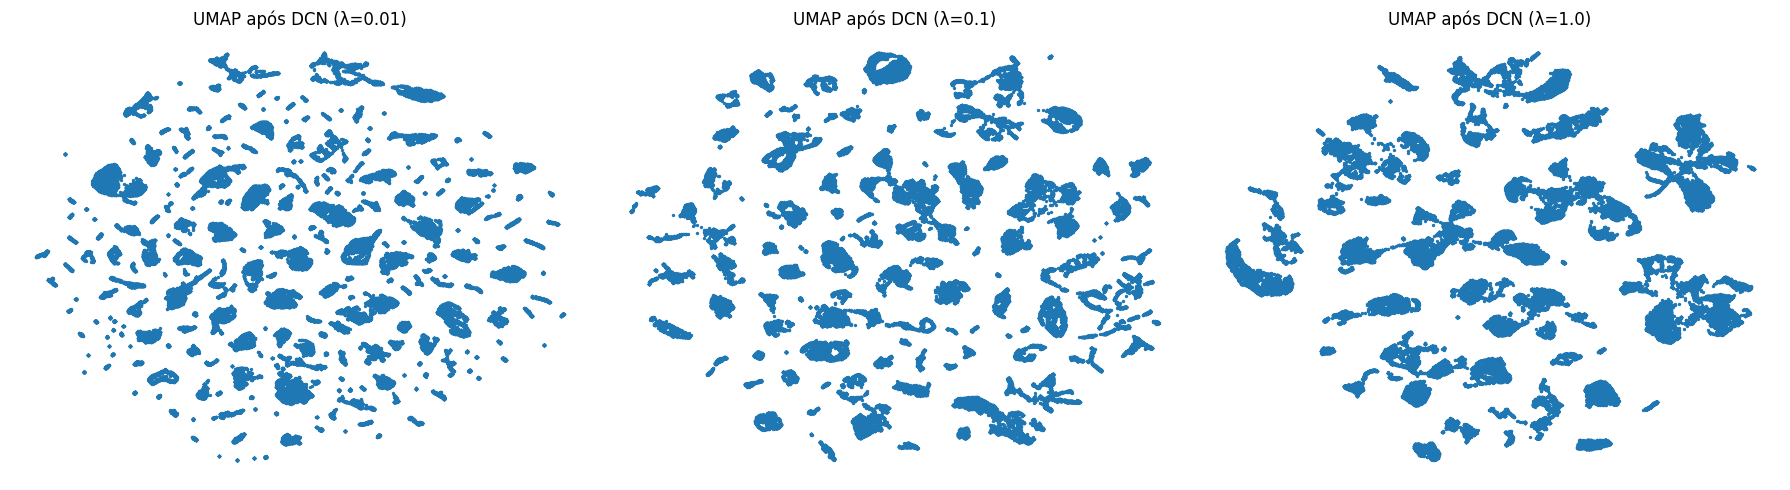

In [ ]:
plt.figure(figsize=(18, 5))

for i, lam in enumerate(lambda_values):
    Z_umap = umap_results[lam]

    ax = plt.subplot(1, 3, i+1)
    plt.scatter(Z_umap[:,0], Z_umap[:,1], s=2)
    plt.title(f"UMAP após DCN (λ={lam})")
    plt.axis("off")

plt.tight_layout()
plt.show()

A análise da variação do peso $\lambda$ demonstra um compromisso crucial para otimizar o espaço latente.

Quando o peso de clustering é baixo ($\lambda=0.01$), o treino é dominado pela reconstrução, resultando em clusters dispersos e mal definidos no UMAP, pois a rede não é penalizada pela falta de coesão do grupo. Por outro lado, aumentar o $\lambda$ para valores intermédios ($\lambda=0.1$) promove o equilíbrio ótimo, levando a uma melhoria clara na densidade e separação dos clusters, sem comprometer significativamente a representação latente para reconstrução.

Finalmente, um valor alto ($\lambda=1.0$) força o agrupamento de forma agressiva, criando clusters densos, mas podendo distorcer a representação latente e introduzir artefactos, potencialmente à custa da fidelidade da reconstrução.

Conclui-se que o valor intermédio de $\lambda=0.1$ ou ligeiramente superior é o mais eficaz para atingir o objetivo de clustering discriminativo.